In [31]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
tf.random.set_seed(99)


In [32]:
# Dataset loading
dataFrame = pd.read_csv(r"F:\geodata\river_runoff_obs\2_dsk_imputMF.csv")[11324 :20798]
# this refers to observed runoff and 10d_mean refers to the runoff with MA
dataFrame.head()

,time,pre,tm,tmax,tmin,10d_mean,dis
11324,1993/1/2,0.011534,-11.116593,-2.894780,-18.375030,NaN,62.8
11325,1993/1/3,0.018250,-11.222269,-5.883377,-18.302631,NaN,53.2
11326,1993/1/4,0.083835,-11.347234,-5.829699,-17.858800,NaN,57.9
11327,1993/1/5,0.000000,-11.997502,-4.580898,-18.537569,NaN,59.8
11328,1993/1/6,0.000000,-11.458523,-6.601076,-18.252735,NaN,61.3


In [33]:
imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
if 'time' in dataFrame.columns:
	dataFrame.drop(columns=['time'], inplace=True)
dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
dataFrame = dataFrame.reset_index(drop=True)
# Applying feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(dataFrame.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
target_scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled[['10d_mean', 'dis']] = target_scaler.fit_transform(dataFrame[['10d_mean', 'dis']].to_numpy())
df_scaled = df_scaled.astype(float)


In [34]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['10d_mean', 'dis']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)


In [35]:
## Data spliting

In [36]:
# Dataset splitting
SPLIT = 0.85
(xVal, yVal) = singleStepSampler(df_scaled, 20)
X_train = xVal[:int(SPLIT * len(xVal))]
y_train = yVal[:int(SPLIT * len(yVal))]
X_test = xVal[int(SPLIT * len(xVal)):]
y_test = yVal[int(SPLIT * len(yVal)):]


In [37]:
print(X_train.shape  )

(8035, 20, 6)


In [38]:
multivariate_lstm = keras.Sequential()
multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
multivariate_lstm.add(keras.layers.Dropout(0.2))
multivariate_lstm.add(keras.layers.Dense(2, activation='linear'))
multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
multivariate_lstm.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 200)               165600    
                                                                 
 dropout_1 (Dropout)         (None, 200)               0         
                                                                 
 dense_1 (Dense)             (None, 2)                 402       
                                                                 
Total params: 166,002
Trainable params: 166,002
Non-trainable params: 0
_________________________________________________________________


In [39]:
# Model training
history = multivariate_lstm.fit(X_train, y_train, epochs=256)

Epoch 1/256
252/252 [==============================] - 3s 9ms/step - loss: 0.0024 - MAE: 0.0323
Epoch 2/256
252/252 [==============================] - 2s 9ms/step - loss: 0.0011 - MAE: 0.0220
Epoch 3/256
252/252 [==============================] - 2s 9ms/step - loss: 9.9727e-04 - MAE: 0.0202
Epoch 4/256
252/252 [==============================] - 2s 9ms/step - loss: 9.4049e-04 - MAE: 0.0198
Epoch 5/256
252/252 [==============================] - 2s 9ms/step - loss: 8.2411e-04 - MAE: 0.0182
Epoch 6/256
252/252 [==============================] - 2s 9ms/step - loss: 7.7842e-04 - MAE: 0.0174
Epoch 7/256
252/252 [==============================] - 2s 9ms/step - loss: 7.5633e-04 - MAE: 0.0168
Epoch 8/256
252/252 [==============================] - 2s 9ms/step - loss: 7.2257e-04 - MAE: 0.0165
Epoch 9/256
252/252 [==============================] - 2s 9ms/step - loss: 6.9239e-04 - MAE: 0.0161
Epoch 10/256
252/252 [==============================] - 2s 9ms/step - loss: 7.0148e-04 - MAE: 0.0160
Epoch 1

In [40]:
import matplotlib.pyplot as plt

In [41]:
# Reload the data with the date index
dataFrame = pd.read_csv(r"I:\GlacierData\river_runoff_obs\2_dsk_imputMF.csv")[11324:20798] # Assuming the CSV file contains a 'Date' column
dataFrame['time'] = pd.to_datetime(dataFrame['time'])
dataFrame.set_index('time', inplace=True)

# Forecast Plot with Dates on X-axis
predicted_values = multivariate_lstm.predict(X_test)

d = {
	'Predicted_10_average': predicted_values[:, 0],
	'Predicted_runoff': predicted_values[:, 1],
	'Actual_10_average': y_test[:, 0],
	'Actual_runoff': y_test[:, 1],
}

d = pd.DataFrame(d)
d.index = dataFrame.index[-len(y_test):] # Assigning the correct date index

45/45 [==============================] - 0s 4ms/step


In [42]:
import pandas as pd
import numpy as np

# Observed and predicted data
observed = d['Actual_runoff']
predicted = d['Predicted_runoff']

# Correlation Coefficient (CC)
CC = d['Predicted_runoff'].corr(d['Actual_runoff'])

# Nash-Sutcliffe Efficiency (NSE)
mean_observed = np.mean(observed)
NSE = 1 - (np.sum((observed - predicted) ** 2) / np.sum((observed - mean_observed) ** 2))

# Kling-Gupta Efficiency (KGE)
mean_predicted = np.mean(predicted)
std_observed = np.std(observed)
std_predicted = np.std(predicted)
r = np.corrcoef(observed, predicted)[0, 1]
alpha = std_predicted / std_observed
beta = mean_predicted / mean_observed
KGE = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Root-Mean-Square Error (RMSE)
RMSE = np.sqrt(np.mean((predicted - observed) ** 2))

# Mean Absolute Relative Error (MARE)
MARE = np.mean(np.abs((observed - predicted) / mean_observed))

# Percent Bias (PBIAS)
PBIAS = 100 * np.sum(predicted - observed) / np.sum(observed)

# Coefficient of Determination (R²)
SS_res = np.sum((observed - predicted) ** 2)
SS_tot = np.sum((observed - mean_observed) ** 2)
R2 = 1 - (SS_res / SS_tot)

# Print all metrics
print("Correlation Coefficient (CC):", CC)
print("Nash-Sutcliffe Efficiency (NSE):", NSE)
print("Kling-Gupta Efficiency (KGE):", KGE)
print("Root-Mean-Square Error (RMSE):", RMSE)
print("Mean Absolute Relative Error (MARE):", MARE)
print("Percent Bias (PBIAS):", PBIAS)
print("Coefficient of Determination (R²):", R2)


Correlation Coefficient (CC): 0.9138503284038334
Nash-Sutcliffe Efficiency (NSE): 0.8167517002120627
Kling-Gupta Efficiency (KGE): 0.8982422018342461
Root-Mean-Square Error (RMSE): 0.044749416022039405
Mean Absolute Relative Error (MARE): 0.20144790219716746
Percent Bias (PBIAS): 4.432400408423817
Coefficient of Determination (R²): 0.8167517002120627


In [43]:
# Calculate Model Evaluation Criteria
# Calculate the correlation coefficient
correlation_coefficient = d['Predicted_runoff'].corr(d['Actual_runoff'])

# Calculate NSE in Python
# Calculate the mean of observed data
mean_observed = np.mean(d['Actual_runoff'])

# Calculate the numerator (sum of squared differences between observed and predicted)
numerator = np.sum((d['Actual_runoff'] - d['Predicted_runoff']) ** 2)

# Calculate the denominator (sum of squared differences between observed and mean observed)
denominator = np.sum((d['Actual_runoff'] - mean_observed) ** 2)

# Calculate the NSE
NSE = 1 - (numerator / denominator)

print("Nash-Sutcliffe Efficiency (NSE):", NSE)


# Calculate the squared differences
squared_differences = (d['Predicted_runoff'] - d['Actual_runoff']) ** 2

# Calculate the mean of the squared differences
mean_squared_error = np.mean(squared_differences)

# Calculate the RMSE
RMSE = np.sqrt(mean_squared_error)
print("RMSE:", RMSE)

Nash-Sutcliffe Efficiency (NSE): 0.8167517002120627
RMSE: 0.044749416022039405


ConversionError: Failed to convert value(s) to axis units: '2018-01-01'

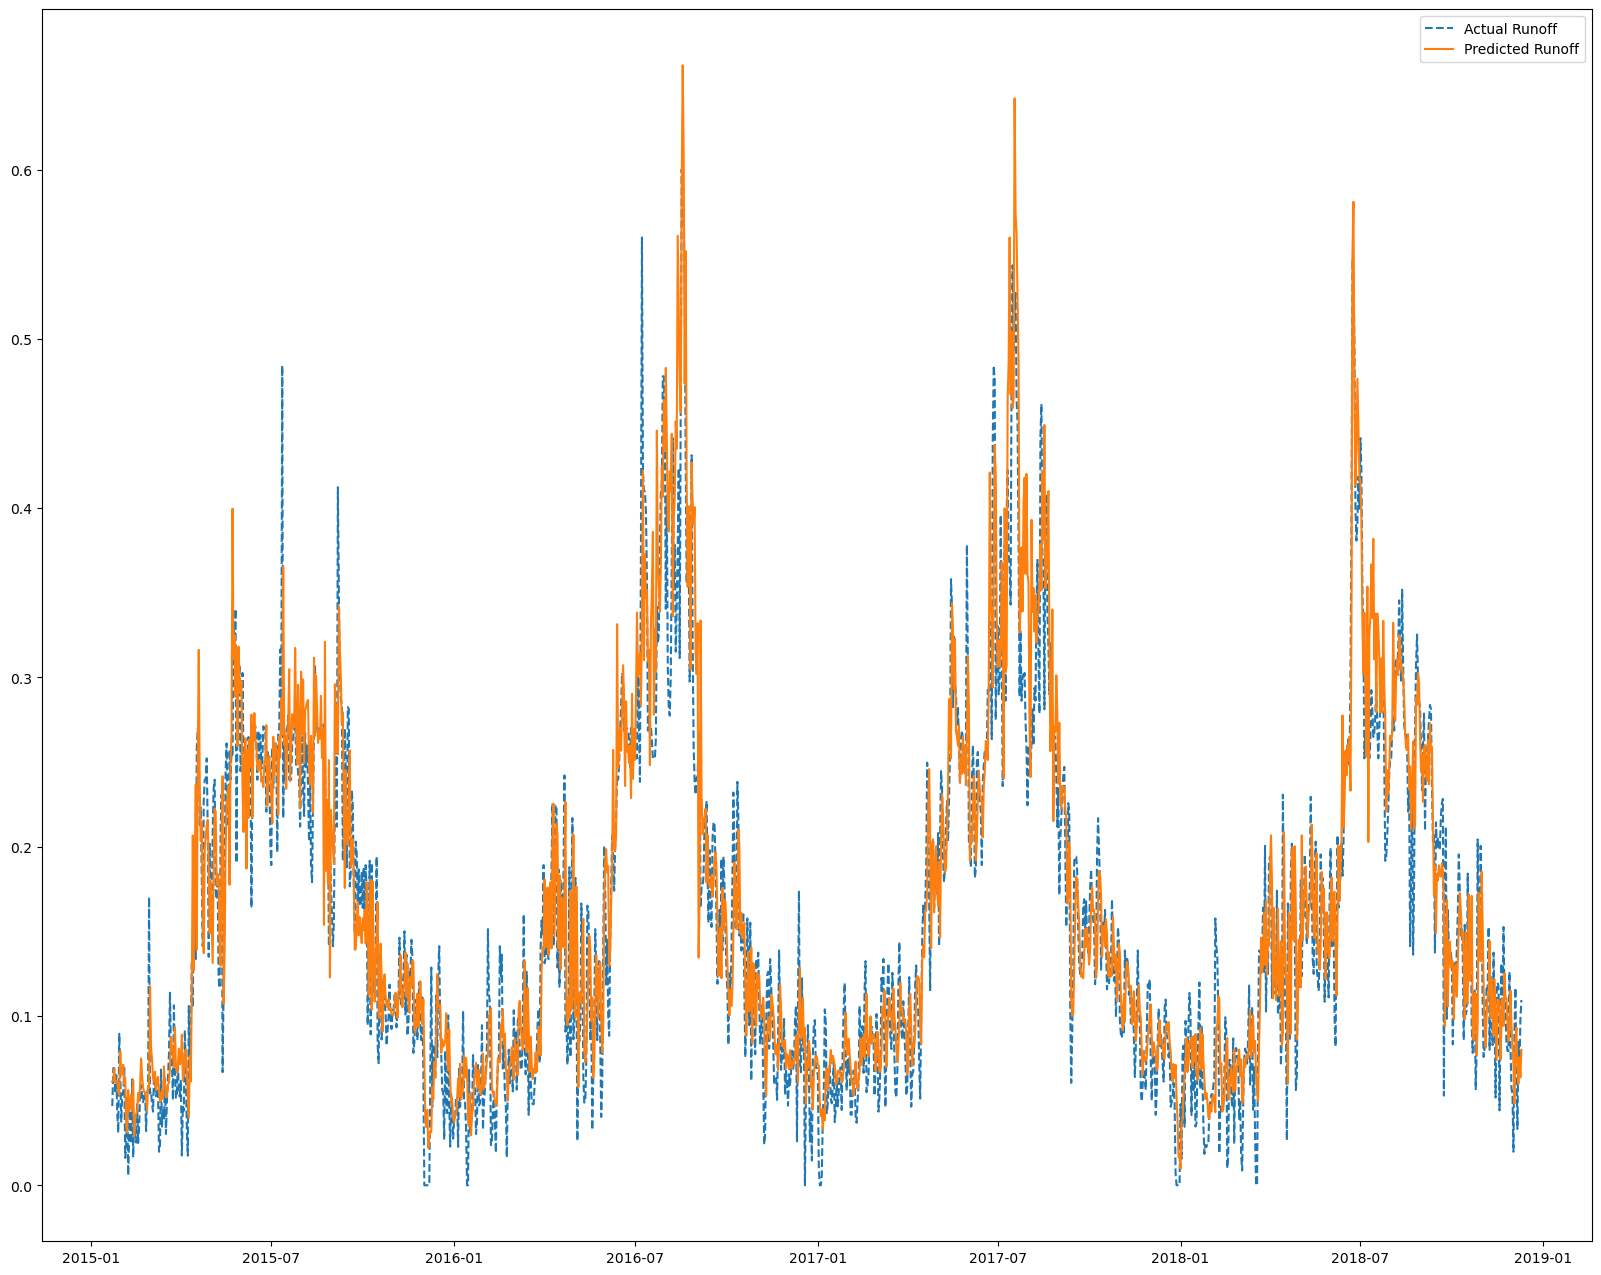

In [44]:
import matplotlib.pyplot as plt

# Assuming `d` is your DataFrame and it has columns 'Predicted_runoff' and 'Actual_runoff'
fig, ax = plt.subplots(figsize=(20, 16))

# Plot the data with specific labels for the legend
ax.plot(d['Actual_runoff'], linestyle='--', label='Actual Runoff')
ax.plot(d['Predicted_runoff'], linestyle='-', label='Predicted Runoff')

# Add the legend to the plot
ax.legend()

# Optionally, you can add a title to the legend and customize its location, fontsize, etc.
# ax.legend(title="Runoff Types", loc="upper right", fontsize=12)

# Set x-axis limits to show data only between 2018 and 2019
ax.set_xlim(['2018-01-01', '2019-12-31'])

plt.show()


In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
# highlight the forecast
highlight_start = int(len(d) * 0.9)
highlight_end = len(d) - 1 # Adjusted to stay within bounds
# Plot the actual values
plt.plot(d[['Actual_Open', 'Actual_Close']][:highlight_start], label=['Actual_10_average', 'Actual_runoff'])

# Plot predicted values with a dashed line
plt.plot(d[['Predicted_Open', 'Predicted_Close']], label=['Predicted_10_average', 'Predicted_runoff'], linestyle='--')

# Highlight the forecasted portion with a different color
plt.axvspan(d.index[highlight_start], d.index[highlight_end], facecolor='lightgreen', alpha=0.5, label='Forecast')

plt.title('Multivariate Time-Series forecasting using LSTM')
plt.xlabel('Dates')
plt.ylabel('Values')
ax.legend()
plt.show()
